# 🍎 Asian Fruits Quality Grading & Detection
### Dataset: "A Dataset of Common Asian Fruits for Quality Grading and Biodiversity Research"
- **Mendeley Data DOI**: `10.17632/bz65dz2pbj.1`
- **Download Link**: `https://data.mendeley.com/public-api/zip/bz65dz2pbj/download/1`
- **Fruit Types (6)**: Apple, Banana, Burmese_grape, Mango, Papaya, Tomato
- **Quality Grades (3)**: 1st grade (Good/Fresh), 2nd grade (Medium), 3rd grade (Bad/Rotten)
- **Total Images**: 3,167 samples (224 × 224 resolution)
- **Classification Tasks Supported**:
  1. **Joint Fruit + Quality Classification (18 classes)**: `apple_good`, `apple_medium`, `banana_bad`, etc.
  2. **Quality-Only Grading (3 classes)**: `good`, `medium`, `bad`

In [ ]:
import os
import sys
import glob
import zipfile
import urllib.request
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset Configuration & Unpacking
Handles automated archive extraction, including nested archives like `Fruits Grade.zip`.

In [ ]:
DATASET_URL = "https://data.mendeley.com/public-api/zip/bz65dz2pbj/download/1"
DATA_DIR = "./data/asian_fruits"
ZIP_PATH = "./data/asian_fruits_dataset.zip"

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.001

# Task Mode:
# - 'fruit_quality' : 18 classes (fruit x quality grade, e.g. apple_good, banana_bad)
# - 'quality_only'  : 3 classes (good, medium, bad across all fruits)
TASK_MODE = "fruit_quality"

FRUITS = ["apple", "banana", "burmese_grape", "burmese grape", "mango", "papaya", "tomato"]

# Map 1st grade, 2nd grade, 3rd grade to good, medium, bad
GRADE_MAP = {
    "1st grade": "good",
    "1st_grade": "good",
    "1st": "good",
    "first grade": "good",
    "good": "good",
    "2nd grade": "medium",
    "2nd_grade": "medium",
    "2nd": "medium",
    "second grade": "medium",
    "medium": "medium",
    "3rd grade": "bad",
    "3rd_grade": "bad",
    "3rd": "bad",
    "third grade": "bad",
    "bad": "bad"
}
QUALITIES = ["good", "medium", "bad"]

def extract_all_nested_zips(target_dir):
    """Recursively unpacks any nested .zip files like 'Fruits Grade.zip'."""
    if not os.path.exists(target_dir):
        return False
    extracted_any = False
    while True:
        found_zip = None
        for root, _, files in os.walk(target_dir):
            for file in files:
                if file.lower().endswith(".zip") and not file.endswith(".extracted"):
                    found_zip = os.path.join(root, file)
                    break
            if found_zip:
                break
        if not found_zip:
            break
        parent_dir = os.path.dirname(found_zip)
        print(f"[INFO] Unpacking nested archive: {os.path.basename(found_zip)}")
        print(f"       into: {parent_dir}...")
        try:
            with zipfile.ZipFile(found_zip, "r") as z:
                z.extractall(parent_dir)
            extracted_any = True
            marker = found_zip + ".extracted"
            if not os.path.exists(marker):
                os.rename(found_zip, marker)
        except Exception as e:
            print(f"[WARNING] Could not unpack {found_zip}: {e}")
            break
    return extracted_any

def download_and_extract_dataset(url=DATASET_URL, zip_path=ZIP_PATH, extract_to=DATA_DIR):
    """Downloads or detects an uploaded Asian Fruits dataset archive and extracts all contents."""
    os.makedirs(os.path.dirname(zip_path) or ".", exist_ok=True)
    os.makedirs(extract_to, exist_ok=True)

    # 1. Check if dataset already has images
    existing_images = (
        glob.glob(os.path.join(extract_to, "**", "*.jpg"), recursive=True) +
        glob.glob(os.path.join(extract_to, "**", "*.png"), recursive=True) +
        glob.glob(os.path.join(extract_to, "**", "*.jpeg"), recursive=True)
    )
    if len(existing_images) > 50:
        print(f"[INFO] Dataset already present at: {extract_to} ({len(existing_images)} images found).")
        return extract_to

    # Unpack nested archives like Fruits Grade.zip if already extracted
    if extract_all_nested_zips(extract_to):
        existing_images = (
            glob.glob(os.path.join(extract_to, "**", "*.jpg"), recursive=True) +
            glob.glob(os.path.join(extract_to, "**", "*.png"), recursive=True) +
            glob.glob(os.path.join(extract_to, "**", "*.jpeg"), recursive=True)
        )
        if len(existing_images) > 50:
            print(f"[INFO] Unpacked nested archives! {len(existing_images)} images ready in {extract_to}.")
            return extract_to

    # 2. Check if a ZIP file already exists locally or was uploaded to Colab
    candidate_zips = [
        zip_path,
        "bz65dz2pbj-1.zip",
        "asian_fruits_dataset.zip",
        os.path.join("./data", "asian_fruits_dataset.zip"),
        os.path.join("/content", "bz65dz2pbj-1.zip"),
        os.path.join("/content", "asian_fruits_dataset.zip"),
        os.path.join("/content/data", "asian_fruits_dataset.zip"),
    ] + glob.glob("*.zip") + glob.glob("./data/*.zip") + glob.glob("/content/*.zip") + glob.glob("/content/data/*.zip")

    found_zip = None
    for cand in candidate_zips:
        if os.path.exists(cand) and os.path.isfile(cand) and os.path.getsize(cand) > 1024 * 1024:
            found_zip = cand
            break

    if found_zip:
        print(f"[INFO] Found dataset archive: {found_zip} ({os.path.getsize(found_zip)/(1024*1024):.1f} MB)")
        print(f"[INFO] Extracting {found_zip} to {extract_to}...")
        with zipfile.ZipFile(found_zip, "r") as zip_ref:
            zip_ref.extractall(extract_to)

        extract_all_nested_zips(extract_to)
        extracted = (
            glob.glob(os.path.join(extract_to, "**", "*.jpg"), recursive=True) +
            glob.glob(os.path.join(extract_to, "**", "*.png"), recursive=True) +
            glob.glob(os.path.join(extract_to, "**", "*.jpeg"), recursive=True)
        )
        print(f"[INFO] Extraction successful! {len(extracted)} images ready in {extract_to}.")
        return extract_to

    # 3. Attempt automated download from Mendeley
    print(f"[INFO] Downloading dataset from: {url}")
    headers = {
        "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9"
    }

    download_success = False
    try:
        import requests
        with requests.get(url, headers=headers, stream=True, allow_redirects=True, timeout=90) as r:
            if r.status_code == 200:
                total_len = r.headers.get("content-length")
                total_length = int(total_len) if total_len and total_len.isdigit() else None
                downloaded = 0
                block_size = 1024 * 1024
                with open(zip_path, "wb") as out_file:
                    for chunk in r.iter_content(chunk_size=block_size):
                        if chunk:
                            out_file.write(chunk)
                            downloaded += len(chunk)
                            if total_length:
                                pct = (downloaded / total_length) * 100
                                sys.stdout.write(f"\rDownloading: {downloaded / (1024*1024):.1f}MB / {total_length / (1024*1024):.1f}MB ({pct:.1f}%)")
                            else:
                                sys.stdout.write(f"\rDownloading: {downloaded / (1024*1024):.1f}MB")
                            sys.stdout.flush()
                print("\n[INFO] Download finished successfully.")
                download_success = True
            else:
                print(f"[WARNING] Mendeley returned HTTP status: {r.status_code}")
    except Exception as err:
        print(f"[WARNING] Download via requests failed: {err}")

    if not download_success:
        try:
            req = urllib.request.Request(url, headers=headers)
            with urllib.request.urlopen(req, timeout=90) as response, open(zip_path, "wb") as out_file:
                total_len = response.headers.get("content-length")
                total_length = int(total_len) if total_len and total_len.isdigit() else None
                downloaded = 0
                block_size = 1024 * 1024
                while True:
                    buffer = response.read(block_size)
                    if not buffer:
                        break
                    downloaded += len(buffer)
                    out_file.write(buffer)
                    if total_length:
                        pct = (downloaded / total_length) * 100
                        sys.stdout.write(f"\rDownloading: {downloaded / (1024*1024):.1f}MB / {total_length / (1024*1024):.1f}MB ({pct:.1f}%)")
                    else:
                        sys.stdout.write(f"\rDownloading: {downloaded / (1024*1024):.1f}MB")
                    sys.stdout.flush()
                print("\n[INFO] Download finished successfully via urllib.")
                download_success = True
        except Exception as err:
            print(f"[WARNING] Download via urllib failed: {err}")

    # 4. Extract archive
    if download_success and os.path.exists(zip_path) and os.path.getsize(zip_path) > 1024 * 1024:
        print(f"[INFO] Extracting {zip_path} to {extract_to}...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_to)
        extract_all_nested_zips(extract_to)
        extracted = (
            glob.glob(os.path.join(extract_to, "**", "*.jpg"), recursive=True) +
            glob.glob(os.path.join(extract_to, "**", "*.png"), recursive=True) +
            glob.glob(os.path.join(extract_to, "**", "*.jpeg"), recursive=True)
        )
        print(f"[INFO] Extraction completed to {extract_to}! ({len(extracted)} images ready)")
        return extract_to

    return extract_to

# Run dataset acquisition
download_and_extract_dataset(DATASET_URL, ZIP_PATH, DATA_DIR)

[INFO] Downloading dataset from: https://data.mendeley.com/public-api/zip/bz65dz2pbj/download/1
[WARNING] Mendeley returned HTTP status: 403
Downloading: 3001.8MB / 3001.8MB (100.0%)
[INFO] Download finished successfully via urllib.
[INFO] Extracting ./data/asian_fruits_dataset.zip to ./data/asian_fruits...
[INFO] Unpacking nested archive: Fruits Grade.zip
       into: ./data/asian_fruits/A Dataset of Common Asian Fruits for Quality Grading and Biodiversity Research...
[INFO] Extraction completed to ./data/asian_fruits! (3167 images ready)


'./data/asian_fruits'

## 2. Load Dataset & Auto-Discover Fruit Structure
Scans `Fruit grade/<Fruit>/<Grade>` hierarchy and structures labels.

In [ ]:
def find_dataset_root(base_dir):
    """Locates the root directory containing fruit folders, checking candidate locations."""
    valid_names = set(FRUITS + [f.replace(" ", "_") for f in FRUITS] + [f.replace("_", " ") for f in FRUITS] + [f.replace(" ", "") for f in FRUITS])
    candidate_dirs = [
        base_dir,
        "./data/asian_fruits",
        "/content/data/asian_fruits",
        "./asian_fruits",
        "/content/asian_fruits",
        "/content",
        "."
    ]

    for candidate in candidate_dirs:
        if not os.path.exists(candidate) or not os.path.isdir(candidate):
            continue

        for root, dirs, files in os.walk(candidate):
            matching = [d for d in dirs if d.lower().strip() in valid_names or d.lower().replace(" ", "_") in valid_names]
            if len(matching) >= 2:
                print(f"[INFO] Found fruit dataset root: {root}")
                return root

    return base_dir

def load_asian_fruits_data(base_path, image_size=224, mode="fruit_quality"):
    # Unpack any nested archives (e.g. Fruits Grade.zip)
    for p in [base_path, "./data/asian_fruits", "/content/data/asian_fruits", "./asian_fruits", "/content"]:
        if os.path.exists(p):
            extract_all_nested_zips(p)

    root_dir = find_dataset_root(base_path)
    print(f"[INFO] Loading dataset from: {root_dir} (Mode: {mode})")

    image_paths = []
    class_labels = []
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    for current_dir, _, files in os.walk(root_dir):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext in valid_exts:
                full_path = os.path.join(current_dir, file)
                rel_parts = os.path.relpath(full_path, root_dir).split(os.sep)

                fruit_found = None
                quality_found = None

                # Inspect path segments for fruit name and quality grade
                for part in rel_parts[:-1]:
                    part_clean = part.lower().strip().replace("-", " ").replace("_", " ")

                    # Check quality grade (matches '1st grade', '2nd grade', '3rd grade', etc.)
                    if not quality_found:
                        for g_key, g_val in GRADE_MAP.items():
                            if g_key in part_clean:
                                quality_found = g_val
                                break

                    # Check fruit category
                    if not fruit_found:
                        for f in FRUITS:
                            f_clean = f.lower().strip().replace("-", " ").replace("_", " ")
                            if f_clean in part_clean or f_clean.replace(" ", "") in part_clean.replace(" ", ""):
                                fruit_found = f.replace(" ", "_").lower()
                                break

                # Fallback: inspect filename if not in folder names
                if not quality_found:
                    file_clean = file.lower().replace("-", " ").replace("_", " ")
                    for g_key, g_val in GRADE_MAP.items():
                        if g_key in file_clean:
                            quality_found = g_val
                            break

                if mode == "fruit_quality":
                    if fruit_found and quality_found:
                        label_name = f"{fruit_found}_{quality_found}"
                    elif len(rel_parts) >= 3:
                        label_name = f"{rel_parts[-3].lower()}_{rel_parts[-2].lower()}"
                    elif len(rel_parts) >= 2:
                        label_name = rel_parts[-2].lower()
                    else:
                        continue
                elif mode == "quality_only":
                    if quality_found:
                        label_name = quality_found
                    elif len(rel_parts) >= 2 and any(q in rel_parts[-2].lower() for q in QUALITIES):
                        label_name = next(q for q in QUALITIES if q in rel_parts[-2].lower())
                    else:
                        continue

                image_paths.append(full_path)
                class_labels.append(label_name)

    if not image_paths:
        raise FileNotFoundError(f"No images found in '{root_dir}'.")

    categories = sorted(list(set(class_labels)))
    cat_to_idx = {cat: idx for idx, cat in enumerate(categories)}

    print(f"[INFO] Found {len(image_paths)} images across {len(categories)} classes:")
    for cat in categories:
        count = class_labels.count(cat)
        print(f"  - {cat:25s}: {count:4d} images")

    images = []
    targets = []
    print("[INFO] Reading and resizing images...")
    for idx, (img_p, cat_name) in enumerate(zip(image_paths, class_labels)):
        img_bgr = cv2.imread(img_p)
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (image_size, image_size))
        images.append(img_resized)
        targets.append(cat_to_idx[cat_name])
        if (idx + 1) % 500 == 0 or (idx + 1) == len(image_paths):
            print(f"  Processed {idx + 1}/{len(image_paths)} images...")

    return np.array(images), np.array(targets), categories

# Load data
X, Y, cate = load_asian_fruits_data(DATA_DIR, image_size=IMAGE_SIZE, mode=TASK_MODE)

[INFO] Unpacking nested archive: asian_fruits_dataset.zip
       into: /content/data...
[INFO] Unpacking nested archive: Fruits Grade.zip
       into: /content/data/A Dataset of Common Asian Fruits for Quality Grading and Biodiversity Research...
[INFO] Found fruit dataset root: ./data/asian_fruits/A Dataset of Common Asian Fruits for Quality Grading and Biodiversity Research/Fruits Grade/Fruit grade
[INFO] Loading dataset from: ./data/asian_fruits/A Dataset of Common Asian Fruits for Quality Grading and Biodiversity Research/Fruits Grade/Fruit grade (Mode: fruit_quality)
[INFO] Found 3167 images across 18 classes:
  - apple_bad                :  112 images
  - apple_good               :  198 images
  - apple_medium             :  172 images
  - banana_bad               :    2 images
  - banana_good              :  243 images
  - banana_medium            :  239 images
  - burmese_grape_bad        :  165 images
  - burmese_grape_good       :  308 images
  - burmese_grape_medium     :  1

## 3. Stratified Train / Test Split & Normalization
Split 80% for training and 20% for testing with stratification to preserve class balance.

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, stratify=Y
)
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
print(f"Total images : {len(X)}")
print(f"X_train shape: {X_train.shape} | Y_train shape: {Y_train.shape}")
print(f"X_test shape : {X_test.shape}  | Y_test shape : {Y_test.shape}")

Total images : 3167
X_train shape: (2533, 224, 224, 3) | Y_train shape: (2533,)
X_test shape : (634, 224, 224, 3)  | Y_test shape : (634,)


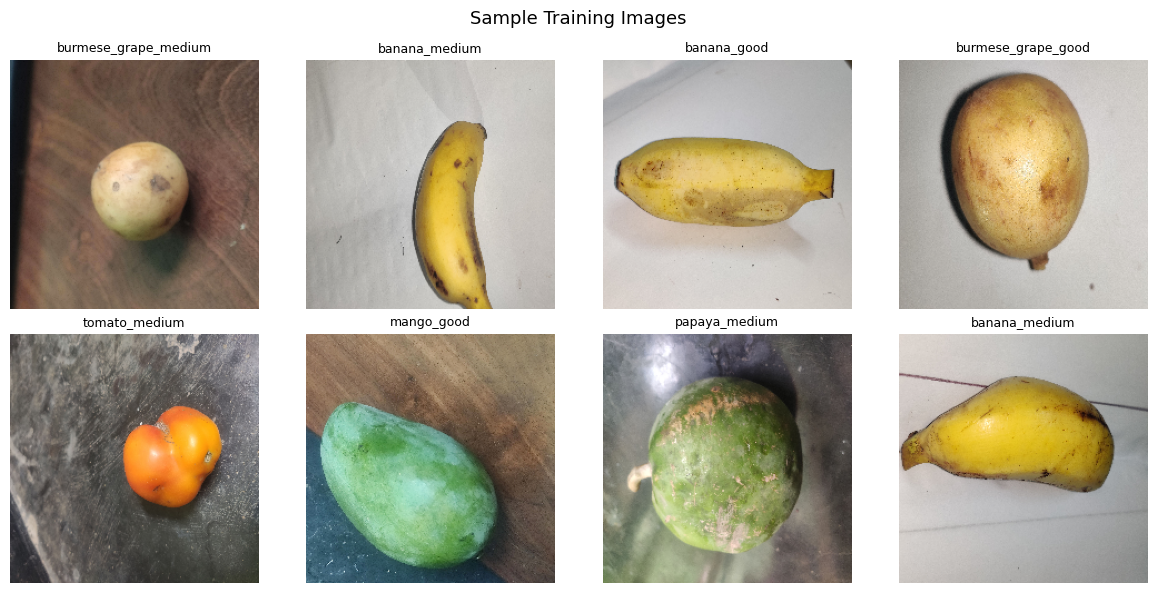

In [ ]:
# Visualize sample images from the training dataset
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < len(X_train):
        ax.imshow(X_train[i])
        ax.set_title(cate[Y_train[i]], fontsize=9)
        ax.axis("off")
plt.suptitle("Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()

## 4. CNN Model Architecture
Multi-layer Convolutional Neural Network with dynamic output units matching `len(cate)`.

In [ ]:
num_classes = len(cate)

model = Sequential([
    # Block 1
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    MaxPool2D(pool_size=(2, 2)),

    # Block 2
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPool2D(pool_size=(2, 2)),

    # Block 3
    Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPool2D(pool_size=(2, 2)),

    # Classifier Head
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,818,834 (98.49 MB)

 Trainable params: 25,818,834 (98.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=adam, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
early_stop = EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)

history = model.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - accuracy: 0.1876 - loss: 2.6442 - val_accuracy: 0.4970 - val_loss: 1.7502
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.4571 - loss: 1.6169 - val_accuracy: 0.6272 - val_loss: 1.1032
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.5617 - loss: 1.2328 - val_accuracy: 0.6450 - val_loss: 0.9858
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.6249 - loss: 1.0008 - val_accuracy: 0.7081 - val_loss: 0.7958
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.6599 - loss: 0.8852 - val_accuracy: 0.7278 - val_loss: 0.7811
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.6811 - loss: 0.8480 - val_accuracy: 0.7081 - val_loss: 0.7405
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.7137 - loss: 0.7219 - val_accuracy: 0.7633 - val_loss: 0.6306
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.7399 - loss: 0.6434 - val_accuracy: 0.7318 -

## 5. Training History & Model Evaluation

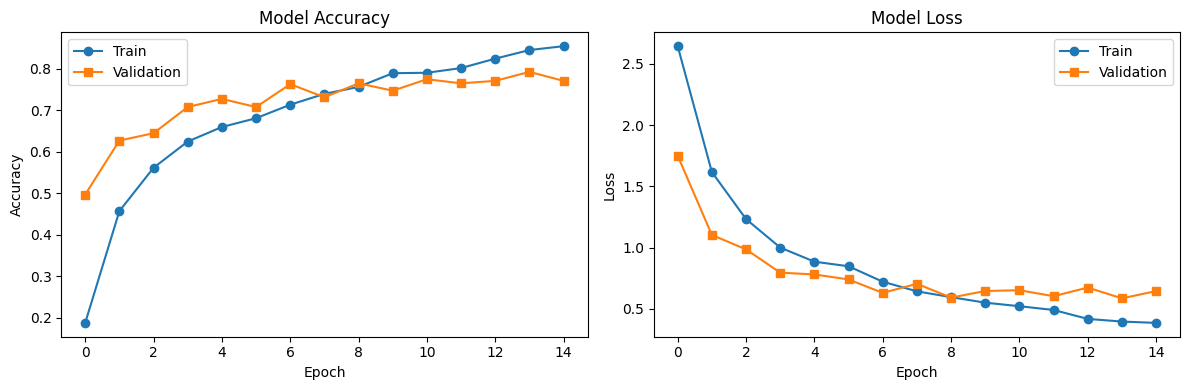

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation', marker='s')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation', marker='s')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
Classification Report:
                      precision    recall  f1-score   support

           apple_bad       0.91      0.95      0.93        22
          apple_good       0.74      0.93      0.82        40
        apple_medium       0.70      0.60      0.65        35
          banana_bad       0.00      0.00      0.00         0
         banana_good       0.58      0.67      0.62        49
       banana_medium       0.59      0.48      0.53        48
   burmese_grape_bad       0.84      0.97      0.90        33
  burmese_grape_good       0.74      0.94      0.83        62
burmese_grape_medium       0.75      0.38      0.50        32
           mango_bad       0.91      0.87      0.89        23
          mango_good       0.80      0.86      0.83        50
        mango_medium       0.84      0.62      0.71        50
          papaya_bad       0.94      0.94      0.94        31
         papaya_good       0.76      0.93      0.84        30
      

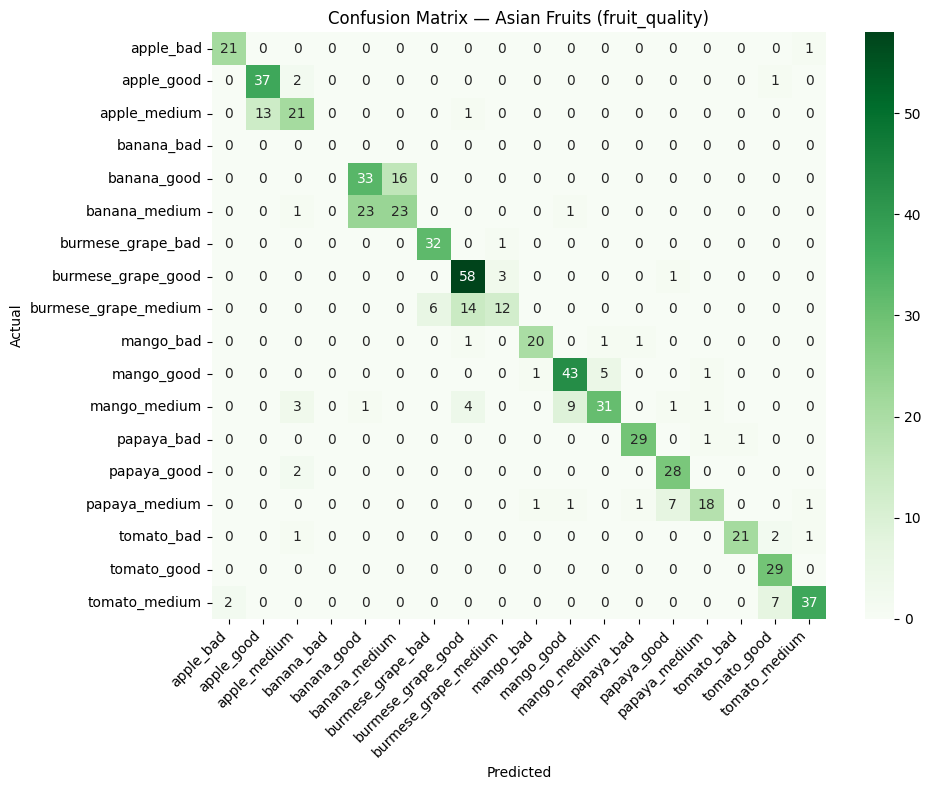

In [ ]:
pred = model.predict(X_test)
pred_cat = pred.argmax(axis=1)

print("Classification Report:")
print(classification_report(
    Y_test,
    pred_cat,
    labels=range(len(cate)),
    target_names=cate,
    zero_division=0
))

tab = confusion_matrix(Y_test, pred_cat, labels=range(len(cate)))
plt.figure(figsize=(10, 8))
sns.heatmap(tab, annot=True, fmt='d', xticklabels=cate, yticklabels=cate, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — Asian Fruits ({TASK_MODE})')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


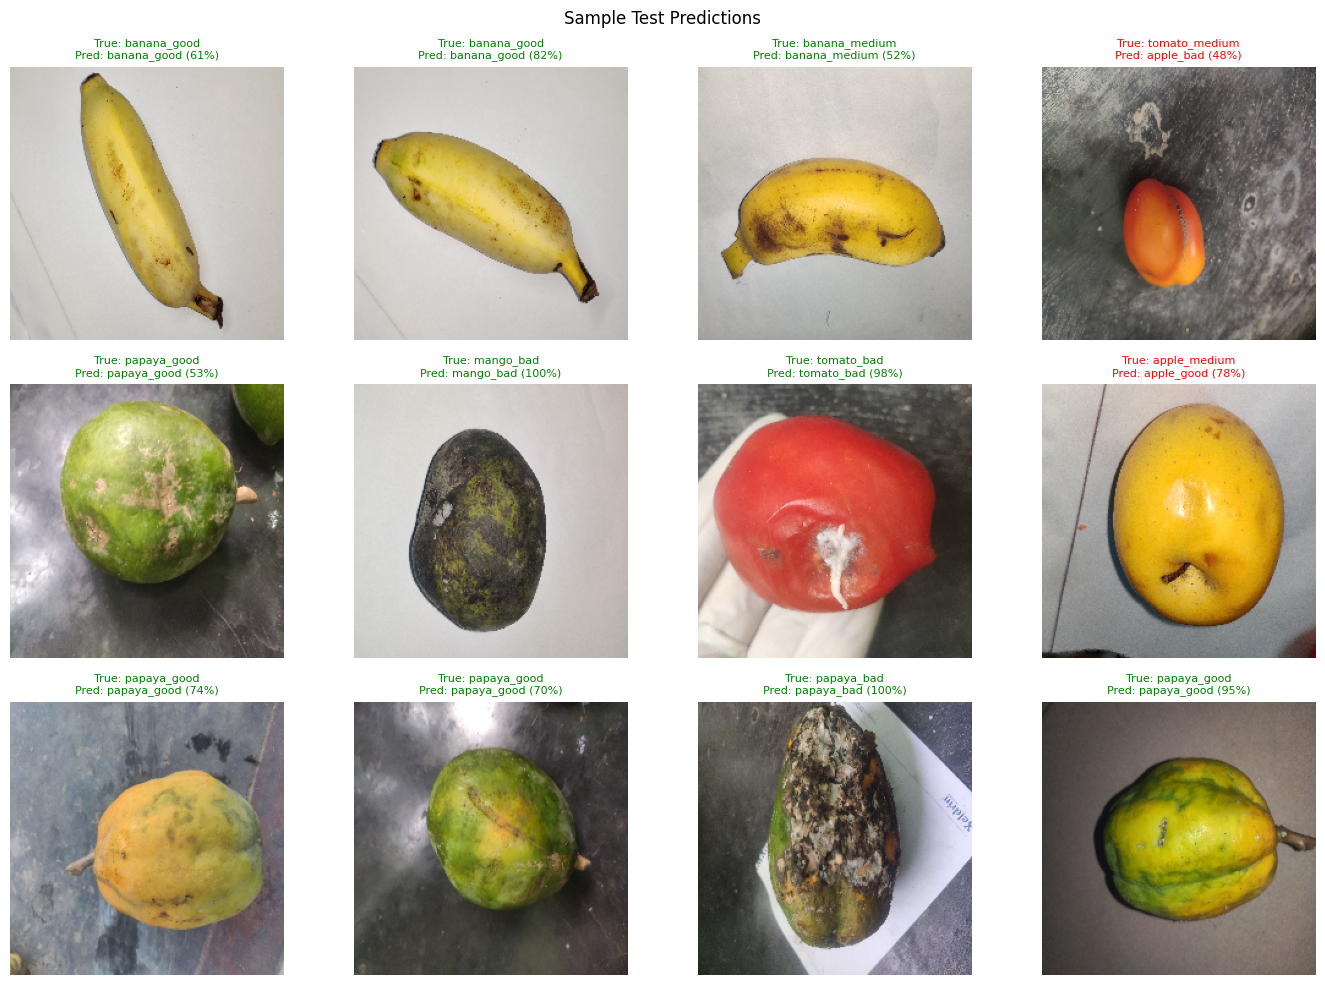

In [ ]:
pred_all = model.predict(X_test, verbose=0)
num_samples = min(12, len(X_test))
indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, ax in zip(indices, axes.flat):
    img = X_test[i]
    true_label = cate[Y_test[i]]
    pred_label = cate[np.argmax(pred_all[i])]
    confidence = np.max(pred_all[i]) * 100

    ax.imshow(img)
    ax.axis('off')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)", color=color, fontsize=8)

plt.suptitle('Sample Test Predictions', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Save Model Checkpoints

In [ ]:
model.save('fruit_quality_model.keras')
print("[INFO] Saved: fruit_quality_model.keras")

model.save('fruit_quality_model.h5')
print("[INFO] Saved: fruit_quality_model.h5")

model.save('fruit_quality_deploy.keras', include_optimizer=False)
print("[INFO] Saved: fruit_quality_deploy.keras (deployment optimized)")

[INFO] Saved: fruit_quality_model.keras
[INFO] Saved: fruit_quality_model.h5
[INFO] Saved: fruit_quality_deploy.keras (deployment optimized)


## 7. Single Image Prediction Function
Inference helper to grade any given input image.

Prediction: mango_good | Confidence: 89.92%


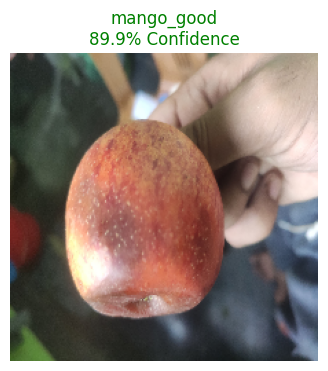

In [ ]:
def predict_single_image(image_path_or_array, model, categories, image_size=224, show_plot=True):
    """Predicts the fruit variety and quality grade for a given image."""
    if isinstance(image_path_or_array, str):
        img_bgr = cv2.imread(image_path_or_array)
        if img_bgr is None:
            raise FileNotFoundError(f"Could not load image: {image_path_or_array}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = image_path_or_array

    img_resized = cv2.resize(img_rgb, (image_size, image_size))
    img_norm = img_resized.astype("float32") / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    preds = model.predict(img_input, verbose=0)[0]
    best_idx = np.argmax(preds)
    pred_label = categories[best_idx]
    confidence = preds[best_idx] * 100.0

    print(f"Prediction: {pred_label} | Confidence: {confidence:.2f}%")

    if show_plot:
        plt.figure(figsize=(4, 4))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f"{pred_label}\n{confidence:.1f}% Confidence", color="green", fontsize=12)
        plt.show()

    return pred_label, confidence

# Example test on first test image:
if 'X_test' in locals() and len(X_test) > 0:
    predict_single_image(X_test[0], model, cate)